### End-to-End Fraud Detection in E-Commerce Transactions Using Machine Learning

### Problem Statement

Online transactions are increasing rapidly, leading to a rise in fraudulent activities. Financial institutions and e-commerce platforms face significant losses due to fraudulent transactions.

The objective of this project is to develop a machine learning-based fraud detection system that identifies fraudulent transactions using transaction and identity-related features, while handling highly imbalanced data and minimizing false negatives.

### Business Objective

* Detect fraudulent transactions early

* Reduce financial losses

* Minimize false negatives (missed frauds)

* Balance precision and recall

* Build a scalable fraud scoring model

### STEP 1 — Import Libraries

In [18]:
# Basic
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc
)


### Inference:
We import libraries for:

* data handling

* visualization

* modeling

* evaluation

### STEP 2 — Load Dataset

In [5]:
train_transaction = pd.read_csv("train_transaction.csv")
train_identity = pd.read_csv("train_identity.csv")

### STEP 3 — Merge Datasets

In [ ]:
train = train_transaction.merge(train_identity,
                                on="TransactionID",
                                how="left")


### Inference:
We merge datasets using TransactionID so each transaction also contains identity/device info.
This improves fraud detection because fraud often depends on device or identity patterns.

In [7]:
train.shape

(590540, 434)

In [8]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.9+ GB


In [9]:
train.describe()

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,...,139369.000000,45113.000000,139318.000000,139261.000000,5159.000000,5169.000000,4747.000000,5132.000000,5163.000000,77586.000000
mean,3.282270e+06,0.034990,7.372311e+06,135.027176,9898.734658,362.555488,153.194925,199.278897,290.733794,86.800630,...,189.451377,14.237337,353.128174,403.882666,368.269820,16.002708,12.800927,329.608924,149.070308,26.508597
std,1.704744e+05,0.183755,4.617224e+06,239.162522,4901.170153,157.793246,11.336444,41.244453,101.741072,2.690623,...,30.375360,1.561302,141.095343,152.160327,198.847038,6.897665,2.372447,97.461089,32.101995,3.737502
min,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000,100.000000,100.000000,10.000000,...,100.000000,10.000000,100.000000,100.000000,100.000000,10.000000,11.000000,100.000000,100.000000,0.000000
25%,3.134635e+06,0.000000,3.027058e+06,43.321000,6019.000000,214.000000,150.000000,166.000000,204.000000,87.000000,...,166.000000,13.000000,266.000000,256.000000,252.000000,14.000000,11.000000,321.000000,119.000000,24.000000
50%,3.282270e+06,0.000000,7.306528e+06,68.769000,9678.000000,361.000000,150.000000,226.000000,299.000000,87.000000,...,166.000000,15.000000,341.000000,472.000000,252.000000,14.000000,11.000000,321.000000,149.000000,24.000000
75%,3.429904e+06,0.000000,1.124662e+07,125.000000,14184.000000,512.000000,150.000000,226.000000,330.000000,87.000000,...,225.000000,15.000000,427.000000,533.000000,486.500000,14.000000,15.000000,371.000000,169.000000,32.000000
max,3.577539e+06,1.000000,1.581113e+07,31937.391000,18396.000000,600.000000,231.000000,237.000000,540.000000,102.000000,...,229.000000,29.000000,671.000000,661.000000,854.000000,44.000000,26.000000,548.000000,216.000000,32.000000


### STEP 4 — Check Target Distribution

In [10]:
train['isFraud'].value_counts(normalize=True)


isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

### Inference:
We check class balance.

Expected result:

Non fraud ≈ 96%

Fraud ≈ 4%

This is highly imbalanced, meaning accuracy is not a good metric.

### STEP 5 — Remove High Missing Columns

In [19]:
missing_ratio = train.isnull().mean()

cols_to_drop = missing_ratio[missing_ratio > 0.8].index

train = train.drop(columns=cols_to_drop)

print("Remaining columns:", train.shape[1])


Remaining columns: 363


### Inference:
Columns with >80% missing values contain little information and add noise.
Dropping them improves model stability and training speed.

### STEP 6 — Fill Missing Values

In [20]:
numeric_cols = train.select_dtypes(include=['int64','float64']).columns
categorical_cols = train.select_dtypes(include=['object']).columns

train[numeric_cols] = train[numeric_cols].fillna(train[numeric_cols].median())
train[categorical_cols] = train[categorical_cols].fillna("Unknown")

### Inference:
Models cannot handle missing values.

Strategy:

numeric → median (robust to outliers)

categorical → “Unknown”


### STEP 7 — Feature Engineering

### * Log Transform Amount

In [22]:
train['TransactionAmt_log'] = np.log1p(train['TransactionAmt'])


### Inference:
Transaction amounts are skewed. Log transformation normalizes distribution and helps model learn patterns better.

### * Transaction Count per Card

In [23]:
train['card1_count'] = train.groupby('card1')['TransactionID'].transform('count')


### Inference:
Fraudsters often reuse cards repeatedly.
This feature captures transaction frequency behavior.

### * Fraud Rate Encoding

In [24]:
fraud_rate = train.groupby('ProductCD')['isFraud'].mean()
train['ProductCD_fraud_rate'] = train['ProductCD'].map(fraud_rate)


### Inference:
Some product types may historically have higher fraud rates.
We encode that knowledge into a feature.

### STEP 8 — Encode Categorical Variables

In [25]:
le = LabelEncoder()

for col in categorical_cols:
    train[col] = le.fit_transform(train[col].astype(str))


### Inference:
ML models need numbers, not text.
Label encoding converts categories into numeric form.

### STEP 9 — Define Features & Target

In [26]:
X = train.drop(['isFraud','TransactionID'], axis=1)
y = train['isFraud']


### Inference:
We remove:

target column

ID column (not predictive)

### STEP 10 — Train Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


### Inference:
stratify=y ensures fraud ratio is same in train and test.
Without this, model evaluation would be misleading.

### STEP 11 — Feature Scaling

In [28]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


### Inference:
Logistic Regression is distance-based.
Scaling ensures all features contribute equally.

### STEP 12 — Train Logistic Regression

In [29]:
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

### Inference:
We use:

high iterations → convergence

balanced weights → handles class imbalance

### STEP 13 — Predictions

In [31]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


### Inference:
We generate:

class predictions

probability scores

Probabilities are needed for ROC and PR curves.

### STEP 14 — Evaluation

### Classification Report

In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.83      0.90    113975
           1       0.13      0.73      0.23      4133

    accuracy                           0.83    118108
   macro avg       0.56      0.78      0.56    118108
weighted avg       0.96      0.83      0.88    118108



### Shows:

Precision

Recall

F1 score

### ROC AUC

In [33]:
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))


ROC AUC Score: 0.8604444106671


### Inference:
Measures model’s ability to distinguish fraud vs non-fraud.

Higher = better.

### Confusion Matrix

In [34]:
print(confusion_matrix(y_test, y_pred))


[[94530 19445]
 [ 1110  3023]]


### Inference:
Shows:

True fraud detected

Fraud missed

False alarms

### STEP 15 — ROC Curve

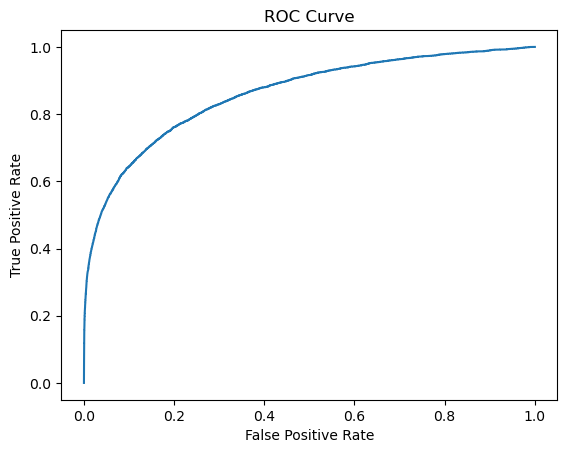

In [35]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


### Inference:
Visual representation of classification performance.

### STEP 16 — Precision Recall Curve

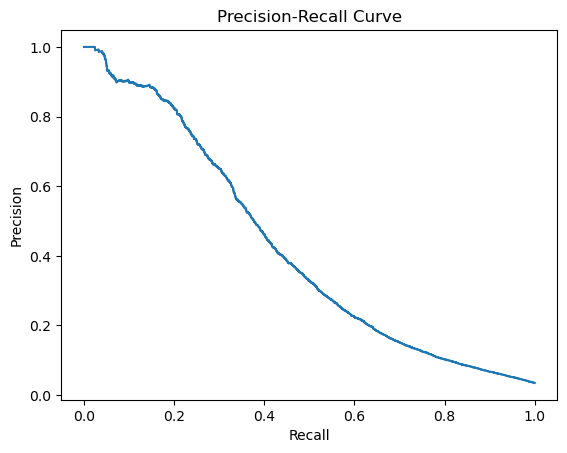

PR AUC: 0.42176757168101364


In [36]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

print("PR AUC:", auc(recall, precision))


### Inference:
Important metric for fraud detection because dataset is imbalanced.

PR curve tells how well model detects fraud cases.

### STEP 17 — Isolation Forest (Anomaly Model)

In [ ]:
iso = IsolationForest(contamination=0.03, random_state=42)
iso.fit(X_train)

iso_pred = iso.predict(X_test)
iso_pred = np.where(iso_pred == -1, 1, 0)

print(classification_report(y_test, iso_pred))

### Inference:
Isolation Forest detects anomalies without labels.
Fraud is treated as anomaly.

This allows comparison:

* supervised vs unsupervised method